# FoodData Central — food × nutrient join

Pivots `food_nutrient.csv` (27.2M long rows) to one row per food, one column per nutrient,
then joins `food.csv` for the descriptions. Amounts are per 100 g.

In [94]:
import pandas as pd
from pathlib import Path

DATA = Path("..")

In [95]:
NUTRIENTS = {
    1008: "energy_kcal",
    1003: "protein_g",
    1004: "fat_g",
    1005: "carb_g",
    1079: "fiber_g",
    2000: "sugars_g",
    1258: "satfat_g",
    1253: "cholesterol_mg",
    1093: "sodium_mg",
}

In [96]:
fn = pd.read_csv(
    DATA / "food_nutrient.csv",
    usecols=["fdc_id", "nutrient_id", "amount"],
    dtype={"fdc_id": "int32", "nutrient_id": "int16", "amount": "float32"},
)
fn = fn[fn["nutrient_id"].isin(NUTRIENTS)].drop_duplicates(subset=["fdc_id", "nutrient_id"])

wide = fn.pivot(index="fdc_id", columns="nutrient_id", values="amount")
wide.columns = [NUTRIENTS[c] for c in wide.columns]
wide.columns.name = None

In [97]:
food = pd.read_csv(
    DATA / "food.csv",
    usecols=["fdc_id", "data_type", "description"],
    dtype={"fdc_id": "int32", "data_type": "category", "description": "string"},
)

df = food.merge(wide, on="fdc_id", how="inner")
print(df.shape)

(1918001, 12)


## Data preprocessing

In [98]:
# drop branded_food — manufacturer-submitted, and the source of every implausible value
before = len(df)
df = df[df["data_type"] != "branded_food"].copy()
df["data_type"] = df["data_type"].cat.remove_unused_categories()

print(f"dropped {before - len(df):,} branded rows -> {len(df):,} remain")
df["data_type"].value_counts()

dropped 1,893,300 branded rows -> 24,701 remain


data_type
sub_sample_food             10199
sr_legacy_food               7793
survey_fndds_food            5431
agricultural_acquisition      810
foundation_food               468
Name: count, dtype: int64

In [99]:
OUT = DATA / "food_nutrients_joined.csv"

df.to_csv(OUT, index=False)
print(f"wrote {OUT}  ({OUT.stat
                       ().st_size/1e6:.0f} MB, {len(df):,} rows)")

wrote ../food_nutrients_joined.csv  (2 MB, 24,701 rows)


Data Analysis

In [100]:
nutrient_cols = [c for c in df.columns if c not in ("fdc_id", "data_type", "description")]

ranges = pd.DataFrame({
    "min":        df[nutrient_cols].min(),
    "median":     df[nutrient_cols].median(),
    "max":        df[nutrient_cols].max(),
    "non_null_%": (df[nutrient_cols].notna().mean() * 100).round(1),
})
ranges


,min,median,max,non_null_%
protein_g,0.000,8.380,88.320000,59.2
fat_g,0.000,4.000,100.000000,72.8
carb_g,-0.705,10.960,100.000000,55.1
energy_kcal,0.000,175.000,902.000000,54.1
fiber_g,0.000,1.200,79.000000,61.3
sodium_mg,0.000,118.000,40700.000000,68.8
cholesterol_mg,0.000,12.000,3100.000000,55.9
satfat_g,0.000,1.686,95.599998,56.1
sugars_g,0.000,1.930,99.800003,46.5


In [101]:
# all negative carb_g — "carbohydrate by difference" = 100 - (water+protein+fat+ash),
# so near-zero-carb foods can round slightly below zero
neg = df[df["carb_g"] < 0].sort_values("carb_g")
neg[["fdc_id", "data_type", "description", "carb_g", "protein_g", "fat_g"]]

,fdc_id,data_type,description,carb_g,protein_g,fat_g
1893449,2727576,foundation_food,"Pork, belly, with skin, raw",-0.70500,15.200000,35.830002
1893448,2727575,foundation_food,"Pork, chop, center cut, raw",-0.56250,22.812500,5.475000
1893439,2727566,foundation_food,"Chicken, drumstick, meat and skin, raw",-0.47505,18.356251,5.940000
1893441,2727568,foundation_food,"Chicken, wing, meat and skin, raw",-0.45875,18.406250,10.640000
1893442,2727569,foundation_food,"Chicken, breast, meat and skin, raw",-0.42825,21.406250,4.777000
1893443,2727570,foundation_food,"Lamb, ground, raw",-0.25080,17.462500,18.639999
1893440,2727567,foundation_food,"Chicken, thigh, meat and skin, raw",-0.17255,17.106251,13.350000
1893444,2727571,foundation_food,"Bison, ground, raw",-0.14955,19.881250,8.880000
1909705,2747673,foundation_food,"Tuna, ahi or yellowfin, frozen, wild caught",-0.10450,24.700001,0.387500
1909688,2747656,foundation_food,"Halibut, frozen, wild caught",-0.06020,19.062500,0.591700


In [102]:
def max_items(frame):
    """For each nutrient column, the item holding the maximum value."""
    rows = []
    for c in nutrient_cols:
        if frame[c].notna().sum() == 0:
            continue
        i = frame[c].idxmax()                      # idxmax skips NaN
        rows.append({
            "nutrient":    c,
            "max":         frame.at[i, c],
            "n_tied":      int((frame[c] == frame[c].max()).sum()),
            "fdc_id":      frame.at[i, "fdc_id"],
            "data_type":   frame.at[i, "data_type"],
            "description": frame.at[i, "description"],
        })
    return pd.DataFrame(rows)


max_items(df)

,nutrient,max,n_tied,fdc_id,data_type,description
0,protein_g,88.320000,2,174276,sr_legacy_food,Soy protein isolate
1,fat_g,100.000000,110,167625,sr_legacy_food,"Oil, whale, bowhead (Alaska Native)"
2,carb_g,100.000000,4,169896,sr_legacy_food,"Sweeteners, tabletop, fructose, dry, powder"
3,energy_kcal,902.000000,9,171400,sr_legacy_food,"Fat, beef tallow"
4,fiber_g,79.000000,1,170289,sr_legacy_food,"Corn bran, crude"
5,sodium_mg,40700.000000,1,321469,sub_sample_food,Salt; iodized
6,cholesterol_mg,3100.000000,2,168624,sr_legacy_food,"Beef, variety meats and by-products, brain, co..."
7,satfat_g,95.599998,1,172342,sr_legacy_food,"Fish oil, menhaden, fully hydrogenated"
8,sugars_g,99.800003,4,169655,sr_legacy_food,"Sugars, granulated"


In [103]:
df

,fdc_id,data_type,description,protein_g,fat_g,carb_g,energy_kcal,fiber_g,sodium_mg,cholesterol_mg,satfat_g,sugars_g
32878,167512,sr_legacy_food,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",5.88,13.24,41.180000,307.0,1.2,1059.0,0.0,2.941000,5.88
32879,167513,sr_legacy_food,"Pillsbury, Cinnamon Rolls with Icing, refriger...",4.34,11.27,53.419998,330.0,1.4,780.0,0.0,3.250000,21.34
32880,167514,sr_legacy_food,"Kraft Foods, Shake N Bake Original Recipe, Coa...",6.10,3.70,79.800003,377.0,NaN,2182.0,NaN,NaN,NaN
32881,167515,sr_legacy_food,"George Weston Bakeries, Thomas English Muffins",8.00,1.80,46.000000,232.0,NaN,345.0,NaN,0.308000,NaN
32882,167516,sr_legacy_food,"Waffles, buttermilk, frozen, ready-to-heat",6.58,9.22,41.049999,273.0,2.2,621.0,15.0,1.898000,4.30
...,...,...,...,...,...,...,...,...,...,...,...,...
1917996,2768896,sub_sample_food,"Alaska Pollock, raw",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.335862,NaN
1917997,2768900,sub_sample_food,"Alaska Pollock, raw",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.162426,NaN
1917998,2768904,sub_sample_food,"Alaska Pollock, raw",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.157785,NaN
1917999,2768908,sub_sample_food,"Alaska Pollock, raw",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.240240,NaN


In [104]:
df.iloc[0]["description"]

'Pillsbury Golden Layer Buttermilk Biscuits, Artificial Flavor, refrigerated dough'

In [105]:
# how many nutrient columns are missing per row
n_nan = df[nutrient_cols].isna().sum(axis=1)

print(f"rows with at least one NaN: {(n_nan > 0).sum():,} / {len(df):,} "
      f"({(n_nan > 0).mean() * 100:.1f}%)")
print(f"rows fully populated:       {(n_nan == 0).sum():,}")

breakdown = n_nan.value_counts().sort_index().rename_axis("n_nan").to_frame("rows")
breakdown["pct"] = (breakdown["rows"] / len(df) * 100).round(2)
display(breakdown)

# drop the near-empty rows: 8 of the 9 nutrient columns missing
threshold = 3
before = len(df)
df = df[n_nan < threshold].copy()
df["data_type"] = df["data_type"].cat.remove_unused_categories()

print(f"dropped {before - len(df):,} rows with 8+ NaN -> {len(df):,} remain")
df["data_type"].value_counts()


rows with at least one NaN: 13,560 / 24,701 (54.9%)
rows fully populated:       11,141


,rows,pct
n_nan,,
0,11141,45.10
1,1382,5.59
2,560,2.27
3,201,0.81
4,180,0.73
5,138,0.56
6,857,3.47
7,146,0.59
8,10096,40.87


dropped 11,618 rows with 8+ NaN -> 13,083 remain


data_type
sr_legacy_food       7580
survey_fndds_food    5431
foundation_food        72
Name: count, dtype: int64

In [106]:
# how many nutrient columns are missing per row
n_nan = df[nutrient_cols].isna().sum(axis=1)

print(f"rows with at least one NaN: {(n_nan > 0).sum():,} / {len(df):,} "
      f"({(n_nan > 0).mean() * 100:.1f}%)")
print(f"rows fully populated:       {(n_nan == 0).sum():,}")

breakdown = n_nan.value_counts().sort_index().rename_axis("n_nan").to_frame("rows")
breakdown["pct"] = (breakdown["rows"] / len(df) * 100).round(2)
display(breakdown)

rows with at least one NaN: 1,942 / 13,083 (14.8%)
rows fully populated:       11,141


,rows,pct
n_nan,,
0,11141,85.16
1,1382,10.56
2,560,4.28


In [107]:
df

,fdc_id,data_type,description,protein_g,fat_g,carb_g,energy_kcal,fiber_g,sodium_mg,cholesterol_mg,satfat_g,sugars_g
32878,167512,sr_legacy_food,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",5.88,13.2400,41.180000,307.0,1.2,1059.000000,0.000000,2.941000,5.88
32879,167513,sr_legacy_food,"Pillsbury, Cinnamon Rolls with Icing, refriger...",4.34,11.2700,53.419998,330.0,1.4,780.000000,0.000000,3.250000,21.34
32882,167516,sr_legacy_food,"Waffles, buttermilk, frozen, ready-to-heat",6.58,9.2200,41.049999,273.0,2.2,621.000000,15.000000,1.898000,4.30
32883,167517,sr_legacy_food,"Waffle, buttermilk, frozen, ready-to-heat, toa...",7.42,9.4900,48.389999,309.0,2.6,710.000000,13.000000,2.275000,4.41
32884,167518,sr_legacy_food,"Waffle, buttermilk, frozen, ready-to-heat, mic...",6.92,9.4000,44.160000,289.0,2.4,663.000000,16.000000,2.057000,4.50
...,...,...,...,...,...,...,...,...,...,...,...,...
1883491,2710811,survey_fndds_food,Vegetables as ingredient in soups,1.87,0.3300,10.560000,50.0,2.0,15.000000,0.000000,0.050000,2.34
1883492,2710812,survey_fndds_food,Vegetables as ingredient in stews,1.77,0.3000,12.670000,59.0,2.6,34.000000,0.000000,0.040000,3.16
1883493,2710813,survey_fndds_food,Sauce as ingredient in hamburgers,1.34,22.8500,17.139999,272.0,0.6,845.000000,13.000000,3.544000,13.08
1883494,2710814,survey_fndds_food,Industrial oil as ingredient in food,0.00,100.0000,0.000000,892.0,0.0,0.000000,0.000000,32.672001,0.00


**Add some additional information (Halal, Hindu, Vegetarian, etc)**

In [108]:
# normalize description, then split on "," into a token array
df["desc_norm"] = (df["description"]
                   .str.lower()
                   .str.replace(r"\s+", " ", regex=True)
                   .str.strip())

df["desc_tokens"] = (df["desc_norm"]
                     .str.split(",")
                     .map(lambda ts: [t.strip() for t in ts if t.strip()]))

df[["description", "desc_norm", "desc_tokens"]].head()

,description,desc_norm,desc_tokens
32878,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","pillsbury golden layer buttermilk biscuits, ar...","[pillsbury golden layer buttermilk biscuits, a..."
32879,"Pillsbury, Cinnamon Rolls with Icing, refriger...","pillsbury, cinnamon rolls with icing, refriger...","[pillsbury, cinnamon rolls with icing, refrige..."
32882,"Waffles, buttermilk, frozen, ready-to-heat","waffles, buttermilk, frozen, ready-to-heat","[waffles, buttermilk, frozen, ready-to-heat]"
32883,"Waffle, buttermilk, frozen, ready-to-heat, toa...","waffle, buttermilk, frozen, ready-to-heat, toa...","[waffle, buttermilk, frozen, ready-to-heat, to..."
32884,"Waffle, buttermilk, frozen, ready-to-heat, mic...","waffle, buttermilk, frozen, ready-to-heat, mic...","[waffle, buttermilk, frozen, ready-to-heat, mi..."


In [109]:
# rule-based keyword sets, matched with word boundaries against desc_norm
NEGATION = r"(?:meatless|meat[- ]free|no meat|non-?meat|vegetarian|vegan|analog)"

PORK = (r"\b(?:pork|ham|bacon|prosciutto|pancetta|lard|salami|pepperoni|chorizo|"
        r"spam|bratwurst|hog|swine)\b")

BEEF = r"\b(?:beef|veal|hamburger|cheeseburger|brisket|pastrami|tallow|oxtail|steer)\b"

# "sirloin" is also a lamb and pork cut, so it only counts as beef when no other species is named
BEEF_AMBIG = r"\b(?:sirloin)\b"
SPECIES    = r"\b(?:pork|lamb|mutton|turkey|chicken|fish|bison|buffalo|goat|venison|duck)\b"

OTHER_MEAT = (r"\b(?:chicken|turkey|lamb|mutton|duck|goat|venison|bison|rabbit|goose|quail|"
              r"pheasant|emu|ostrich|meat|meatball|meatloaf|sausage|frankfurter|hot dog|"
              r"liver|liverwurst|bologna|pate|tripe|sweetbread|poultry)\b")

SEAFOOD = (r"\b(?:fish|shrimp|prawn|crab|lobster|clam|oyster|scallop|squid|octopus|tuna|"
           r"salmon|cod|halibut|anchovy|sardine|mussel|crayfish|caviar|roe|mackerel|herring|"
           r"trout|tilapia|catfish|snapper|pollock|seafood|surimi)\b")

In [110]:
d = df["desc_norm"]
neg = d.str.contains(NEGATION, regex=True)          # "chicken, meatless" -> not meat

df["has_pork"] = d.str.contains(PORK, regex=True) & ~neg
df["has_beef"] = (d.str.contains(BEEF, regex=True)
                  | (d.str.contains(BEEF_AMBIG, regex=True)
                     & ~d.str.contains(SPECIES, regex=True))) & ~neg

# has_meat = any animal flesh, including poultry and seafood
animal = (d.str.contains(PORK, regex=True)
          | d.str.contains(BEEF, regex=True)
          | d.str.contains(OTHER_MEAT, regex=True)
          | d.str.contains(SEAFOOD, regex=True))
df["has_meat"] = (animal | df["has_beef"]) & ~neg

# has_pork / has_beef must imply has_meat
assert ((df["has_pork"] | df["has_beef"]) & ~df["has_meat"]).sum() == 0

for c in ["has_pork", "has_beef", "has_meat"]:
    print(f"{c:<10} {df[c].sum():>6}  ({df[c].mean() * 100:4.1f}%)")

df[["description", "has_pork", "has_beef", "has_meat"]].head(10)

has_pork      763  ( 5.8%)
has_beef     1551  (11.9%)
has_meat     4781  (36.5%)


,description,has_pork,has_beef,has_meat
32878,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",False,False,False
32879,"Pillsbury, Cinnamon Rolls with Icing, refriger...",False,False,False
32882,"Waffles, buttermilk, frozen, ready-to-heat",False,False,False
32883,"Waffle, buttermilk, frozen, ready-to-heat, toa...",False,False,False
32884,"Waffle, buttermilk, frozen, ready-to-heat, mic...",False,False,False
32885,"Waffle, plain, frozen, ready-to-heat, microwave",False,False,False
32886,"Pie Crust, Cookie-type, Graham Cracker, Ready ...",False,False,False
32887,"Pie Crust, Cookie-type, Chocolate, Ready Crust",False,False,False
32888,"Pie, Dutch Apple, Commercially Prepared",False,False,False
32889,"Pie crust, deep dish, frozen, unbaked, made wi...",False,False,False


In [111]:
# See which row has has_pork, has_beef, has_meat = True
total = 0
total_beef = 0
total_pork = 0
total_both = 0

for _, row in df.iterrows():
    if row['has_pork'] or row['has_beef'] or row['has_meat']:
        print(row['description'])
        total+=row['has_meat']
        total_beef+=row['has_beef']
        total_pork+=row['has_pork']
        total_both+=row['has_beef'] and row['has_pork']

print(f"There are {total} rows has meat, {total_beef} has beef, {total_pork} has pork, {total_both} has both")

Snacks, beef jerky, chopped and formed
Moose, meat, raw (Alaska Native)
Fish, salmon, king, chinook, smoked, brined (Alaska Native)
Mutton, cooked, roasted (Navajo)
Frybread, made with lard (Navajo)
Fish, halibut, raw, with skin (Alaska Native)
Fish, salmon, coho (silver), raw (Alaska Native)
Fish, salmon, red, canned, bones removed (Alaska Native)
Fish, whitefish, eggs (Alaska Native)
Caribou, rump meat, half dried (Alaska Native)
Fish, salmon, red, (sockeye), canned, smoked (Alaska Native)
Fish, salmon, red, (sockeye), kippered (Alaska Native)
Fish, salmon, king, with skin, kippered, (Alaska Native)
Fish, sheefish, raw (Alaska Native)
Frybread, made with lard (Apache)
Corned beef and potatoes in tortilla (Apache)
ON THE BORDER, soft taco with ground beef, cheese and lettuce
Restaurant, Mexican, soft taco with ground beef, cheese and lettuce
Restaurant, Latino, chicken and rice, entree, prepared
Restaurant, Latino, empanadas, beef, prepared
Restaurant, Latino, pupusas del cerdo (pupus

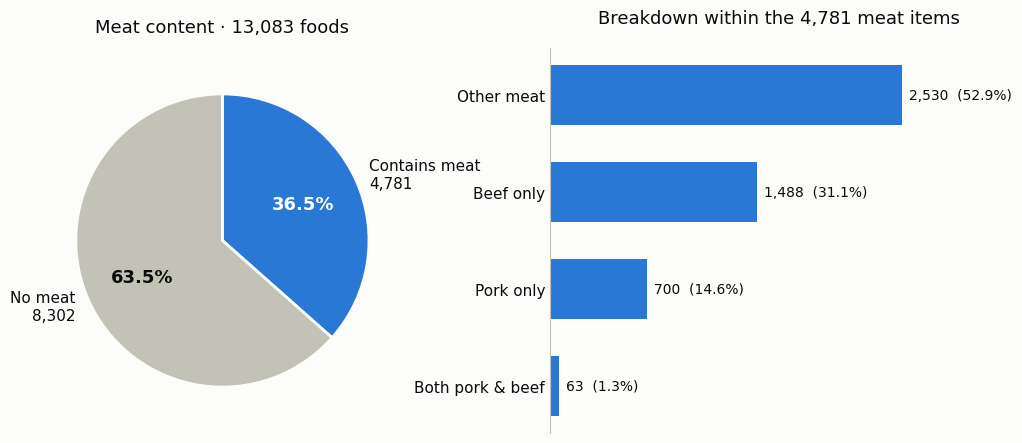

In [112]:
import matplotlib.pyplot as plt

INK, MUTED, SURFACE = "#0b0b0b", "#898781", "#fcfcfb"
BLUE, NEUTRAL = "#2a78d6", "#c3c2b7"

meat = df["has_meat"]
n_meat, n_none = int(meat.sum()), int((~meat).sum())
m = df[meat]

# mutually exclusive segments — pork and beef overlap, so "both" is its own slice
seg = {
    "Other meat":       total-total_both-(total_beef-total_both)-(total_pork-total_both),
    "Beef only":        total_beef-total_both,
    "Pork only":        total_pork-total_both,
    "Both pork & beef": total_both,
}
assert sum(seg.values()) == len(m)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5), facecolor=SURFACE,
                               gridspec_kw={"width_ratios": [1, 1.25], "wspace": 0.35})

# --- meat vs no meat ---
wedges, texts, autotexts = ax1.pie(
    [n_meat, n_none],
    labels=[f"Contains meat\n{n_meat:,}", f"No meat\n{n_none:,}"],
    colors=[BLUE, NEUTRAL], autopct="%1.1f%%",
    startangle=90, counterclock=False,
    wedgeprops={"edgecolor": SURFACE, "linewidth": 2},
    textprops={"color": INK, "fontsize": 11},
)
autotexts[0].set_color("#ffffff")
autotexts[1].set_color(INK)
for t in autotexts:
    t.set_fontsize(13)
    t.set_fontweight("bold")
ax1.set_title(f"Meat content \u00b7 {len(df):,} foods", color=INK, fontsize=13, pad=18)

# --- breakdown within the meat items ---
labels = list(seg)
vals = [seg[k] for k in labels]
ax2.barh(range(len(labels)), vals, color=BLUE, height=0.62)
ax2.set_yticks(range(len(labels)))
ax2.set_yticklabels(labels, fontsize=11)
ax2.invert_yaxis()
for i, v in enumerate(vals):
    ax2.text(v + max(vals) * 0.02, i, f"{v:,}  ({v / len(m) * 100:.1f}%)",
             va="center", color=INK, fontsize=10)
ax2.set_xlim(0, max(vals) * 1.30)
ax2.set_facecolor(SURFACE)
for s in ("top", "right", "bottom"):
    ax2.spines[s].set_visible(False)
ax2.spines["left"].set_color("#c3c2b7")
ax2.tick_params(axis="both", length=0)
for lbl in ax2.get_yticklabels():
    lbl.set_color(INK)
ax2.set_xticks([])
ax2.set_title(f"Breakdown within the {len(m):,} meat items", color=INK, fontsize=13, pad=18)

plt.show()


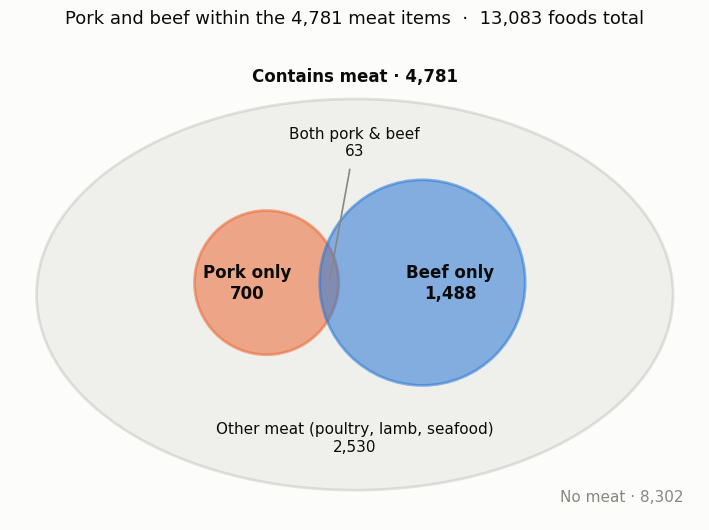

In [113]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Ellipse
import numpy as np

INK, MUTED, SURFACE = "#0b0b0b", "#898781", "#fcfcfb"
BLUE, ORANGE, NEUTRAL = "#2a78d6", "#eb6834", "#c3c2b7"

m = df[df["has_meat"]]
n_pork, n_beef = int(m["has_pork"].sum()), int(m["has_beef"].sum())
both      = int((m["has_pork"] &  m["has_beef"]).sum())
pork_only = n_pork - both
beef_only = n_beef - both
other     = int((~m["has_pork"] & ~m["has_beef"]).sum())
no_meat   = int((~df["has_meat"]).sum())
assert pork_only + beef_only + both + other == len(m)

fig, ax = plt.subplots(figsize=(10, 6.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

# outer: all meat items
ax.add_patch(Ellipse((0, 0), 9.6, 5.9, facecolor=NEUTRAL, alpha=0.22,
                     edgecolor=MUTED, linewidth=2, zorder=1))

# inner circles, radius ~ sqrt(count) so area tracks magnitude
scale = 1.55 / np.sqrt(n_beef)
r_beef, r_pork = scale * np.sqrt(n_beef), scale * np.sqrt(n_pork)
cx_beef, cx_pork, cy = 1.02, -1.33, 0.18

ax.add_patch(Circle((cx_pork, cy), r_pork, facecolor=ORANGE, alpha=0.55,
                    edgecolor=ORANGE, linewidth=2, zorder=3))
ax.add_patch(Circle((cx_beef, cy), r_beef, facecolor=BLUE, alpha=0.55,
                    edgecolor=BLUE, linewidth=2, zorder=3))

ax.text(cx_pork - 0.30, cy, f"Pork only\n{pork_only:,}", ha="center", va="center",
        color=INK, fontsize=12, fontweight="bold", zorder=5)
ax.text(cx_beef + 0.42, cy, f"Beef only\n{beef_only:,}", ha="center", va="center",
        color=INK, fontsize=12, fontweight="bold", zorder=5)
ax.text(0, -2.16, f"Other meat (poultry, lamb, seafood)\n{other:,}",
        ha="center", va="center", color=INK, fontsize=11, zorder=5)

# the overlap sliver is too thin to label in place
mid = (cx_pork + r_pork + cx_beef - r_beef) / 2
ax.annotate(f"Both pork & beef\n{both:,}", xy=(mid, cy), xytext=(0, 2.30),
            ha="center", va="center", color=INK, fontsize=11, zorder=6,
            arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=1.2,
                            shrinkA=6, shrinkB=2))

ax.text(0, 3.30, f"Contains meat · {len(m):,}", ha="center", va="center",
        color=INK, fontsize=12, fontweight="bold", zorder=5)
ax.text(4.95, -3.05, f"No meat · {no_meat:,}", ha="right", va="center",
        color=MUTED, fontsize=11, zorder=5)

ax.set_xlim(-5.2, 5.2); ax.set_ylim(-3.4, 3.8)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"Pork and beef within the {len(m):,} meat items  ·  {len(df):,} foods total",
             color=INK, fontsize=13, pad=14)
plt.show()

**Processing non-food tokens in description**

In [114]:
!pip3 install stanza gliner

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [115]:
from gliner import GLiNER

model = GLiNER.from_pretrained("urchade/gliner_large-v2.1")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [116]:
def get_entities(text, labels):
    result = model.predict_entities(
        text,
        labels,
        threshold=0.6,
    )

    return result

labels = ["origin", "brand", "variant", "product"]

In [ ]:
from tqdm.auto import tqdm

NER_LABELS = [l for l in labels if l != "origin"]  # no origin column here

def build_text(description):
    # a bit of context for the NER; its length is the offset entities must start after
    prefix = "Food item: "
    return prefix + str(description), len(prefix)

def all_entities(entities, labels, offset):
    """Every span the model kept, not just the best-scoring one per label:
    "Bread, cheese" holds two products, and only naming one of them loses the other."""
    found = {l: [] for l in labels}
    for e in sorted(entities, key=lambda e: e["start"]):
        if e["start"] < offset or e["label"] not in found:
            continue
        if e["text"] not in found[e["label"]]:  # the same span can be tagged twice
            found[e["label"]].append(e["text"])
    return [found[l] for l in labels]

def add_entity_columns(
    df, labels, threshold=0.3, batch_size=32
):
    products_dict = {}
    built = [build_text(d) for d in df["description"].fillna("")]
    rows = []

    for i in tqdm(range(0, len(built), batch_size), desc="tagging"):
        chunk = built[i : i + batch_size]
        preds = model.inference(
            [t for t, _ in chunk],
            labels,
            threshold=threshold,
            batch_size=batch_size,
            flat_ner=True,
            multi_label=True,
        )
        rows += [
            all_entities(p, labels, off)
            for p, (_, off) in zip(preds, chunk)
        ]

    # Assign extracted entity columns
    df[labels] = pd.DataFrame(rows, index=df.index, columns=labels)

    # Collect target entity fields per row
    target_fields = [
        "brand",
        "variant",
        "protein_g",
        "fat_g",
        "carb_g",
        "energy_kcal",
        "fiber_g",
        "sodium_mg",
        "cholesterol_mg",
        "satfat_g",
        "sugars_g",
    ]
    available_fields = [col for col in target_fields if col in df.columns]

    if "product" in df.columns:
        for prod_name, entity_data in zip(
            df["product"].astype(str), df[available_fields].to_dict("records")
        ):
            products_dict.setdefault(prod_name, []).append(entity_data)

    return df, products_dict

df, products = add_entity_columns(df, NER_LABELS)
df = df.drop(columns="desc_norm")
df

tagging:   0%|          | 0/409 [00:00<?, ?it/s]

,fdc_id,data_type,description,protein_g,fat_g,carb_g,energy_kcal,fiber_g,sodium_mg,cholesterol_mg,satfat_g,sugars_g,desc_tokens,has_pork,has_beef,has_meat,brand,variant,product
32878,167512,sr_legacy_food,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",5.88,13.2400,41.180000,307.0,1.2,1059.000000,0.000000,2.941000,5.88,"[pillsbury golden layer buttermilk biscuits, a...",False,False,False,[Pillsbury],"[Artificial Flavor, refrigerated dough]","[Golden Layer Buttermilk Biscuits, refrigerate..."
32879,167513,sr_legacy_food,"Pillsbury, Cinnamon Rolls with Icing, refriger...",4.34,11.2700,53.419998,330.0,1.4,780.000000,0.000000,3.250000,21.34,"[pillsbury, cinnamon rolls with icing, refrige...",False,False,False,[Pillsbury],"[Cinnamon Rolls with Icing, refrigerated dough]","[Cinnamon Rolls with Icing, refrigerated dough]"
32882,167516,sr_legacy_food,"Waffles, buttermilk, frozen, ready-to-heat",6.58,9.2200,41.049999,273.0,2.2,621.000000,15.000000,1.898000,4.30,"[waffles, buttermilk, frozen, ready-to-heat]",False,False,False,[buttermilk],"[buttermilk, frozen, ready-to-heat]",[Waffles]
32883,167517,sr_legacy_food,"Waffle, buttermilk, frozen, ready-to-heat, toa...",7.42,9.4900,48.389999,309.0,2.6,710.000000,13.000000,2.275000,4.41,"[waffle, buttermilk, frozen, ready-to-heat, to...",False,False,False,[buttermilk],"[frozen, ready-to-heat, toasted]",[Waffle]
32884,167518,sr_legacy_food,"Waffle, buttermilk, frozen, ready-to-heat, mic...",6.92,9.4000,44.160000,289.0,2.4,663.000000,16.000000,2.057000,4.50,"[waffle, buttermilk, frozen, ready-to-heat, mi...",False,False,False,[buttermilk],"[frozen, ready-to-heat, microwaved]",[Waffle]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1883491,2710811,survey_fndds_food,Vegetables as ingredient in soups,1.87,0.3300,10.560000,50.0,2.0,15.000000,0.000000,0.050000,2.34,[vegetables as ingredient in soups],False,False,False,[],[],"[Vegetables, soups]"
1883492,2710812,survey_fndds_food,Vegetables as ingredient in stews,1.77,0.3000,12.670000,59.0,2.6,34.000000,0.000000,0.040000,3.16,[vegetables as ingredient in stews],False,False,False,[],[],"[Vegetables, stews]"
1883493,2710813,survey_fndds_food,Sauce as ingredient in hamburgers,1.34,22.8500,17.139999,272.0,0.6,845.000000,13.000000,3.544000,13.08,[sauce as ingredient in hamburgers],False,False,False,[Sauce],[hamburgers],[Sauce]
1883494,2710814,survey_fndds_food,Industrial oil as ingredient in food,0.00,100.0000,0.000000,892.0,0.0,0.000000,0.000000,32.672001,0.00,[industrial oil as ingredient in food],False,False,False,[],[],[Industrial oil]


In [118]:
import stanza

stanza.download('en') 
nlp = stanza.Pipeline('en', processors='tokenize,pos')

2026-09-03 16:25:04 INFO: Downloaded file to /Users/tung/Library/Caches/stanza/1.14.0/resources/resources.json
2026-09-03 16:25:04 INFO: Downloading default packages for language: en (English) ...
2026-09-03 16:25:05 INFO: File exists: /Users/tung/Library/Caches/stanza/1.14.0/resources/en/default.zip
2026-09-03 16:25:07 INFO: Finished downloading models and saved to /Users/tung/Library/Caches/stanza/1.14.0/resources
2026-09-03 16:25:07 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-09-03 16:25:08 INFO: Downloaded file to /Users/tung/Library/Caches/stanza/1.14.0/resources/resources.json
2026-09-03 16:25:08 WARNING: Language en package default expects mwt, which has been added
2026-09-03 16:25:08 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined_nocharlm |
| mwt       | combined          |
| pos       | combined_charlm   |

2026-09-03 16:25:08 INFO: Using device: cpu
2026-09-03 16:25:08 INFO: Loading: tokenize
2026-09-03 16:25:08 INFO: Loading: mwt
2026-09-03 16:25:08 INFO: Loading: pos
2026-09-03 16:25:10 INFO: Done loading processors!


In [ ]:
from tqdm import tqdm

pos_tags = []
verbs = []
adjs = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    item_desc = str(row['description'])
    doc = nlp(item_desc)
    row_pos = []
    verb_set = []
    adj_set = []
    for sentence in doc.sentences:
        for word in sentence.words:
            row_pos.append((word.text, word.upos))
            if word.upos == "VERB":
                verb_set.append(word.text)
            elif word.upos == "ADJ":
                adj_set.append(word.text)

    verbs.append(verb_set)
    adjs.append(adj_set)
    pos_tags.append(row_pos)


 31%|███       | 4048/13083 [06:02<13:59, 10.77it/s]  

In [ ]:
pos_tags

[[('Pillsbury', 'PROPN'),
  ('Golden', 'ADJ'),
  ('Layer', 'PROPN'),
  ('Buttermilk', 'PROPN'),
  ('Biscuits', 'PROPN'),
  (',', 'PUNCT'),
  ('Artificial', 'ADJ'),
  ('Flavor', 'NOUN'),
  (',', 'PUNCT'),
  ('refrigerated', 'VERB'),
  ('dough', 'NOUN')],
 [('Pillsbury', 'PROPN'),
  (',', 'PUNCT'),
  ('Cinnamon', 'PROPN'),
  ('Rolls', 'NOUN'),
  ('with', 'ADP'),
  ('Icing', 'NOUN'),
  (',', 'PUNCT'),
  ('refrigerated', 'VERB'),
  ('dough', 'NOUN')],
 [('Waffles', 'NOUN'),
  (',', 'PUNCT'),
  ('buttermilk', 'NOUN'),
  (',', 'PUNCT'),
  ('frozen', 'VERB'),
  (',', 'PUNCT'),
  ('ready', 'ADJ'),
  ('-', 'PUNCT'),
  ('to', 'ADP'),
  ('-', 'PUNCT'),
  ('heat', 'NOUN')],
 [('Waffle', 'NOUN'),
  (',', 'PUNCT'),
  ('buttermilk', 'NOUN'),
  (',', 'PUNCT'),
  ('frozen', 'VERB'),
  (',', 'PUNCT'),
  ('ready', 'ADJ'),
  ('-', 'PUNCT'),
  ('to', 'ADP'),
  ('-', 'PUNCT'),
  ('heat', 'NOUN'),
  (',', 'PUNCT'),
  ('toasted', 'VERB')],
 [('Waffle', 'NOUN'),
  (',', 'PUNCT'),
  ('buttermilk', 'NOUN'),
  ('

In [ ]:
verbs

[['refrigerated'],
 ['refrigerated'],
 ['frozen'],
 ['frozen', 'toasted'],
 ['frozen', 'microwaved'],
 ['frozen'],
 [],
 [],
 ['Prepared'],
 ['frozen', 'unbaked', 'made', 'enriched'],
 ['frozen'],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 ['filled', 'iced'],
 [],
 ['chopped', 'formed'],
 ['based', 'extruded'],
 ['based', 'extruded'],
 ['based', 'extruded'],
 [],
 [],
 [],
 [],
 [],
 [],
 ['combed'],
 [],
 [],
 ['popped'],
 [],
 ['coated'],
 ['coated'],
 ['made', 'dried', 'reduced'],
 ['made', 'dried'],
 ['salted'],
 [],
 [],
 ['salted'],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 ['prepared'],
 [],
 ['serve'],
 [],
 ['prepared'],
 ['prepared'],
 [],
 ['Covered'],
 [],
 [],
 [],
 [],
 [],
 [],
 ['prepared'],
 ['prepared'],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 ['Cultivated'],
 ['Cultivated', 'rehydrated'],
 ['refrigerated'],
 ['refrigerated', 'prepared'],
 ['frozen', 'packaged', 'added'],
 [],
 [],
 ['smoked', 'brined'],
 [],
 

In [ ]:
adjs

[['Golden', 'Artificial'],
 [],
 ['ready'],
 ['ready'],
 ['ready'],
 ['plain', 'ready'],
 ['Ready'],
 ['Ready'],
 ['Dutch'],
 ['deep'],
 ['ready'],
 [],
 ['salvadoran', 'sweet'],
 [],
 [],
 [],
 [],
 [],
 ['white'],
 [],
 [],
 ['ready'],
 [],
 ['plain'],
 [],
 ['plain'],
 [],
 [],
 ['hard', 'plain'],
 ['hard'],
 ['soft', 'uncoated'],
 ['soft', 'coated'],
 [],
 ['soft', 'coated'],
 ['soft', 'uncoated'],
 ['regular', 'trans'],
 [],
 [],
 [],
 [],
 [],
 ['hard', 'plain'],
 ['hard'],
 ['brown'],
 ['plain', 'white'],
 [],
 [],
 ['regular'],
 [],
 [],
 [],
 [],
 [],
 ['unsweetened'],
 ['unsweetened'],
 [],
 [],
 ['white'],
 [],
 ['rich'],
 [],
 [],
 ['light', 'soft'],
 ['orange'],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 ['CHUNKY'],
 [],
 ['dry', 'instant'],
 ['dry', 'regular'],
 ['Free', 'Soft'],
 ['Multi', 'Free'],
 ['Free'],
 ['Free'],
 ['Baked'],
 ['Baked'],
 ['Baked'],
 ['Free', 'Original'],
 ['Soft', 'Delicious', 'White'],
 ['Soft', 'Hearty', 'Whole'],
 ['Free', 'Whole'],
 ['Free', 'Or

In [ ]:
df['verb'] = verbs
df['adj'] = adjs

In [ ]:
df.to_csv("./data/food_nutrients.csv", index=False)